<a href="https://colab.research.google.com/github/waj-ha/child-safety-fars-analysis/blob/main/notebooks/260606_AGE_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis Enssential Tools and Libraries:
These libraries are essential tools for most data science workflows:

*   **NumPy**: Fundamental package for numerical computation, especially with arrays and matrices.
*   **Pandas**: Provides high-performance, easy-to-use data structures and data analysis tools (DataFrames).
*   **Matplotlib**: A comprehensive library for creating static, animated, and interactive visualizations.
*   **Seaborn**: Built on Matplotlib, it provides a high-level interface for drawing attractive and informative statistical graphics.
*   **Scikit-learn**: A robust machine learning library featuring various classification, regression, and clustering algorithms, along with tools for model selection and preprocessing.
*   **Statsmodels**: Provides classes and functions for the estimation of many different statistical models, as well as for conducting statistical tests and statistical data exploration.

The `!pip install` command is used to install Python packages. The `!` at the beginning tells Colab to run the command as a shell command. In this example, `numpy` is the name of the package to be installed.

In [1]:
common_data_science_libraries = [
    "numpy",        # Numerical operations
    "pandas",       # Data manipulation and analysis
    "matplotlib",   # Basic plotting
    "seaborn",      # Enhanced statistical data visualization
    "statsmodels",  # Statistical modeling
    "requests",     # HTTP requests for web data
]

# Install all listed libraries
!pip install {" ".join(common_data_science_libraries)}



In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt # Import pyplot for plotting functions
import seaborn as sns
import sklearn
import tensorflow as tf

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}") # Access version from the main module
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# You can add simple verification tests here if needed, for example:
# print(np.array([1, 2, 3]) + np.array([4, 5, 6]))
# print(pd.DataFrame({'A': [1, 2], 'B': [3, 4]}))

NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
TensorFlow version: 2.20.0


### Dataset Import Techniques
Raw data is placed at Github;

https://github.com/waj-ha/child-safety-fars-analysis.git

and accessed, and imported via Pandas Libraries. The files sizes are more than 100MB. So, these are

In [3]:
import pandas as pd
#url_accident = 'https://media.githubusercontent.com/media/waj-ha/child-safety-fars-analysis/refs/heads/main/data/raw/accident.csv'
#df_raw_accident = pd.read_csv(url_accident,encoding='unicode_escape', dtype=str, low_memory=False)
url_person = 'https://media.githubusercontent.com/media/waj-ha/child-safety-fars-analysis/refs/heads/main/data/raw/person.csv'
df_raw_person = pd.read_csv(url_person,encoding='unicode_escape', dtype=str, low_memory=False)
#url_vehicle = 'https://media.githubusercontent.com/media/waj-ha/child-safety-fars-analysis/refs/heads/main/data/raw/vehicle.csv'
#df_raw_vehicle = pd.read_csv(url_vehicle,encoding='unicode_escape', dtype=str, low_memory=False)

### EDA

In [4]:
def dataset_overview(df, dataset_name):
    print("*****************")
    print(f"{dataset_name} Dataset:")
    print("*****************")
    print("\nShape:", df.shape)
    print("\nCount:")
    print(df.nunique().sort_values(ascending=False))
    print("\nData Types:")
    print(df.dtypes.value_counts(ascending=False))
    print("\nDuplicates:", df.duplicated().sum())
    print(f"\nMissing Values Count:")
    missing_values = (df.isnull().sum().sort_values(ascending=False))
    non_zero_missing_values = missing_values[missing_values > 0]
    print(non_zero_missing_values)
    print(f"\nMissing Values Percentage:")
    missing_percentage = round(df.isnull().sum() * 100 / len(df), 2).sort_values(ascending=False)
    non_zero_missing_percentage = missing_percentage[missing_percentage > 0]
    print(non_zero_missing_percentage)
    print("\n---------------------------------------------------\n")

dataset_overview(df_raw_person, "Person")


*****************
Person Dataset:
*****************

Shape: (88326, 126)

Count:
ST_CASE          36297
VPICMODEL         2381
VPICMODELNAME     2325
DEATH_TM          1457
DEATH_TMNAME      1457
                 ...  
EXTRICATNAME         3
FIRE_EXPNAME         2
FIRE_EXP             2
SCH_BUSNAME          2
SCH_BUS              2
Length: 126, dtype: int64

Data Types:
object    126
Name: count, dtype: int64

Duplicates: 0

Missing Values Count:
VPICMAKE             9020
MOD_YEAR             9020
VPICMODEL            9020
VPICMAKENAME         9020
MOD_YEARNAME         9020
FIRE_EXPNAME         9020
FIRE_EXP             9020
IMPACT1NAME          9020
IMPACT1              9020
ROLLOVERNAME         9020
ROLLOVER             9020
EMER_USENAME         9020
EMER_USE             9020
SPEC_USENAME         9020
SPEC_USE             9020
TOW_VEHNAME          9020
TOW_VEH              9020
GVWR_TONAME          9020
GVWR_TO              9020
GVWR_FROMNAME        9020
GVWR_FROM            9020
ICF

Relevant Variables:

**`ST_CASE`**: Identify the crash case and Unique ID.

**`AGE`**: Identify the age groups and risk difference.

**`SEX`**: Compare outcomes in males and females.

**`PER_TYP`**: Identify the type of perssenger. Occupant/Pedestrain.

**`RESTRAINT_USE`**: Compare the impact of use of restaint Systems and seatbelts.

**`SEAT_POS`**: Analyses seat position Effects.

**`INJ_SEV`**: Measure Crash outcomes.

**`BODY_TYP`**: Compare Vehicle types.

**`HOUR`**: Study Time of the day patterns.

**`WEATHER`**: Examine environmental conditions.

**`SPEEDING`**: Assess influence of speed related crashes

**`RURAL_URBAN`**: Compare rural or urban crash characteristics.

**`STATE`**: Compare the US states.


# `AGE`
This data element identifies the person’s age in years on the date of the crash.
According to reference manual, the valid age is between 0-120.

[Fatality Analysis Reporting System Analytical User’s Manual, 1975-2024](https://github.com/waj-ha/child-safety-fars-analysis/blob/6c3be83f1700cb93c8d3a495211a92ccfd7aea08/references/Fatality%20Analysis%20Reporting%20System%20Analytical%20User%E2%80%99s%20Manual%2C%201975-2024.pdf)

(Page 296)


In [35]:
df_person_age = df_raw_person.copy()
df_person_age['AGE'].unique()

array(['50', '42', '47', '23', '19', '60', '66', '31', '28', '25', '48',
       '999', '45', '29', '53', '15', '62', '16', '998', '22', '24', '46',
       '65', '39', '40', '59', '32', '70', '52', '54', '68', '33', '58',
       '27', '44', '37', '71', '34', '35', '8', '11', '30', '57', '55',
       '36', '61', '17', '49', '63', '21', '74', '72', '56', '20', '77',
       '38', '78', '18', '73', '43', '14', '75', '41', '67', '82', '87',
       '51', '69', '26', '79', '85', '7', '13', '4', '76', '90', '3',
       '12', '5', '6', '10', '81', '89', '64', '80', '2', '84', '83', '1',
       '9', '86', '0', '88', '94', '93', '91', '95', '97', '96', '92',
       '101', '98', '99', '100'], dtype=object)

From FARS reference manual, we know the outliers are defined with special codes. For **`AGE`** these code are,

*   `998` = Unknow
*   `999` = Not Reported

To get the real age distribution, rows with these codes should be removed.


# NaN Method

In [39]:
df_person_age_m1 = df_person_age.replace(['998', '999'], np.nan)
df_person_age_m1['AGE'].unique()

array(['50', '42', '47', '23', '19', '60', '66', '31', '28', '25', '48',
       nan, '45', '29', '53', '15', '62', '16', '22', '24', '46', '65',
       '39', '40', '59', '32', '70', '52', '54', '68', '33', '58', '27',
       '44', '37', '71', '34', '35', '8', '11', '30', '57', '55', '36',
       '61', '17', '49', '63', '21', '74', '72', '56', '20', '77', '38',
       '78', '18', '73', '43', '14', '75', '41', '67', '82', '87', '51',
       '69', '26', '79', '85', '7', '13', '4', '76', '90', '3', '12', '5',
       '6', '10', '81', '89', '64', '80', '2', '84', '83', '1', '9', '86',
       '0', '88', '94', '93', '91', '95', '97', '96', '92', '101', '98',
       '99', '100'], dtype=object)

In [45]:
# convert dtype to float64 usinfg coerce.
df_person_age_m1_numeric = pd.to_numeric(df_person_age_m1['AGE'], errors='coerce')

In [56]:
df_person_age_m1_numeric.unique(), df_person_age_m1_numeric.dtype,
df_person_age_m1_numeric.shape, df_person_age_m1_numeric.isna().sum()

((88326,), np.int64(2253))

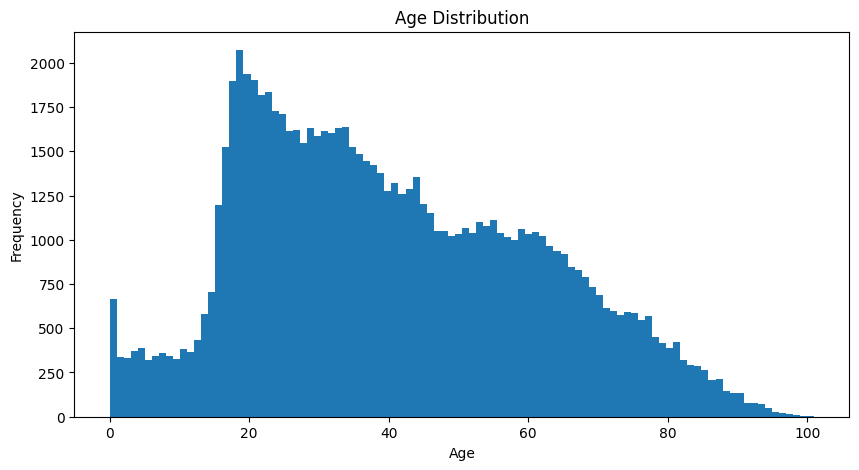

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_person_age_m1_numeric.dropna(), bins=100)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# Method Data Frame Manipolation

In [61]:
df_person_age_m2 = df_raw_person.copy()
df_person_age_m2 = df_person_age_m2[df_person_age_m2['AGE'] != '998']
df_person_age_m2 = df_person_age_m2[df_person_age_m2['AGE'] != '999']
df_person_age_m2['AGE'] = pd.to_numeric(df_person_age_m2['AGE'])
df_person_age_m2.shape
df_person_age_m2['AGE'].unique()


array([ 50,  42,  47,  23,  19,  60,  66,  31,  28,  25,  48,  45,  29,
        53,  15,  62,  16,  22,  24,  46,  65,  39,  40,  59,  32,  70,
        52,  54,  68,  33,  58,  27,  44,  37,  71,  34,  35,   8,  11,
        30,  57,  55,  36,  61,  17,  49,  63,  21,  74,  72,  56,  20,
        77,  38,  78,  18,  73,  43,  14,  75,  41,  67,  82,  87,  51,
        69,  26,  79,  85,   7,  13,   4,  76,  90,   3,  12,   5,   6,
        10,  81,  89,  64,  80,   2,  84,  83,   1,   9,  86,   0,  88,
        94,  93,  91,  95,  97,  96,  92, 101,  98,  99, 100])

Text(0, 0.5, 'Frequency')

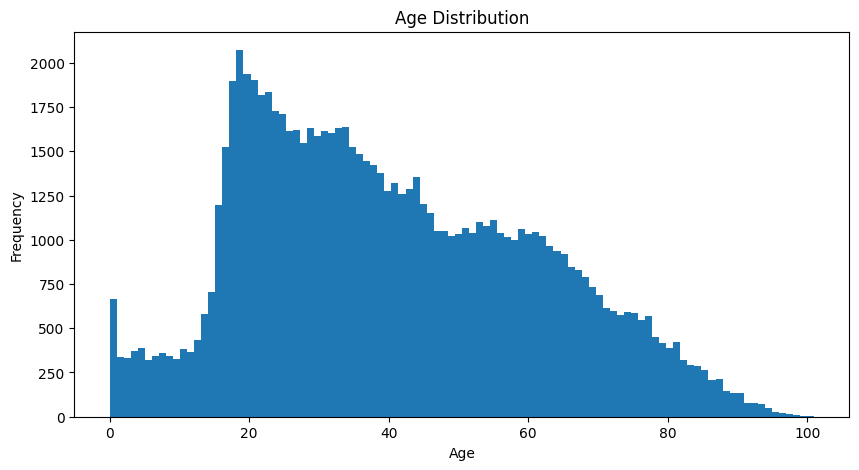

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_person_age_m2['AGE'], bins=100)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

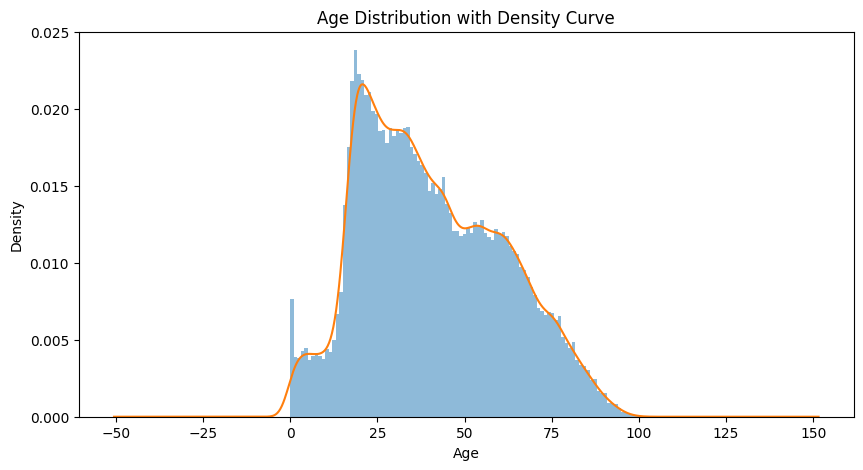

In [69]:
age = df_person_age_m2['AGE']

plt.figure(figsize=(10,5))

plt.hist(
    age,
    bins=100,
    density=True,
    alpha=0.5
)

age.plot(kind='density')

plt.title('Age Distribution with Density Curve')
plt.xlabel('Age')

plt.show()

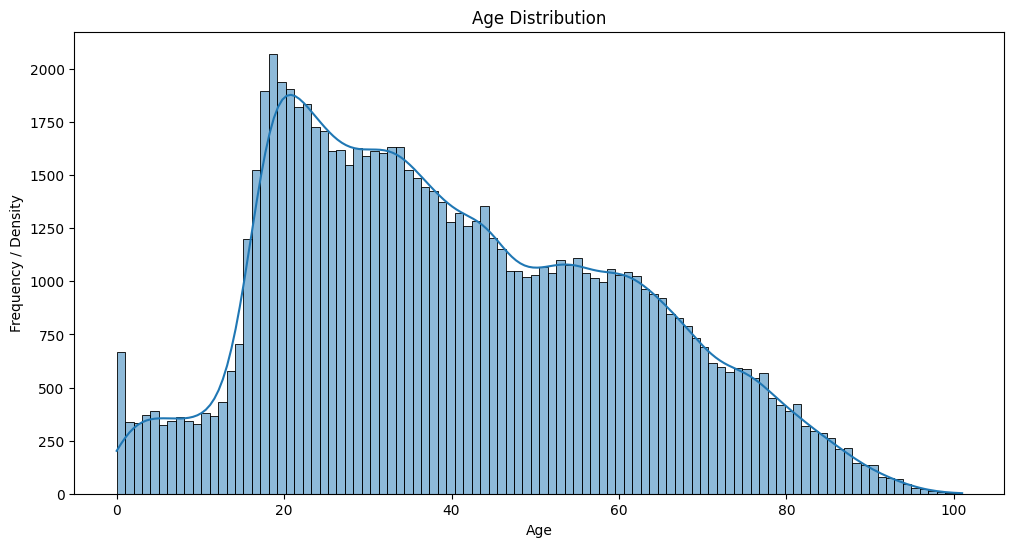

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(age, bins=100, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')

plt.show()

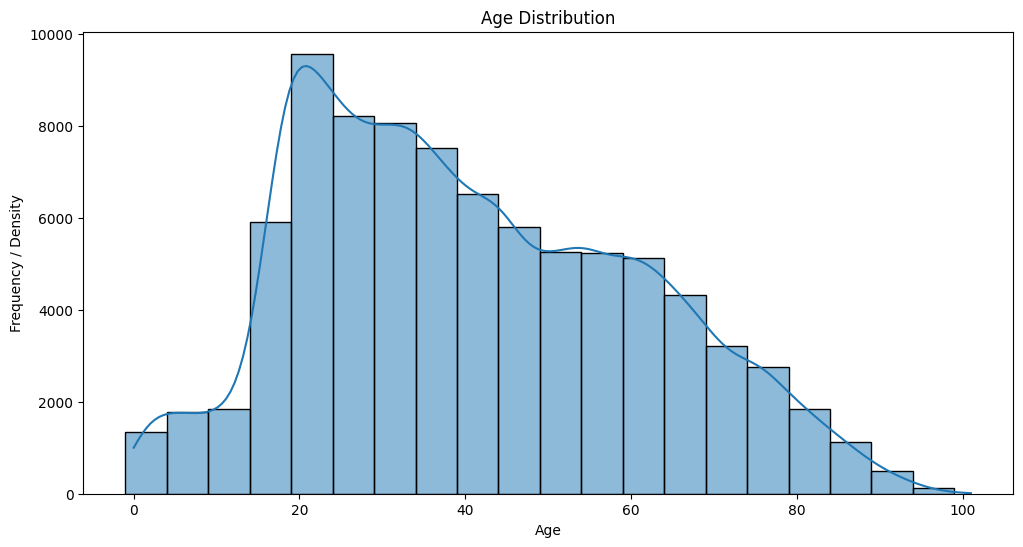

,AGE
count,86073.000000
mean,40.614397
std,20.408336
min,0.000000
25%,24.000000
50%,38.000000
75%,56.000000
max,101.000000


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(age, bins=range(-1,101,5), kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')

plt.show()
age.describe()

In [94]:
round(age.mean(), 2), age.median(), round(age.std(), 2), age.min(), age.max(), age.quantile(0.25), age.quantile(0.75)

(np.float64(40.61), 38.0, 20.41, 0, 101, np.float64(24.0), np.float64(56.0))

**Mean Age (rounded to 2 decimal places)**: 40.61

**Median Age:** 38.0

**Standard Deviation of Age:** 20.41

**Minimum Age:** 0

**Maximum Age:** 101

**25th Percentile (Q1) of Age:** 24.0

**75th Percentile (Q3) of Age:** 56.0


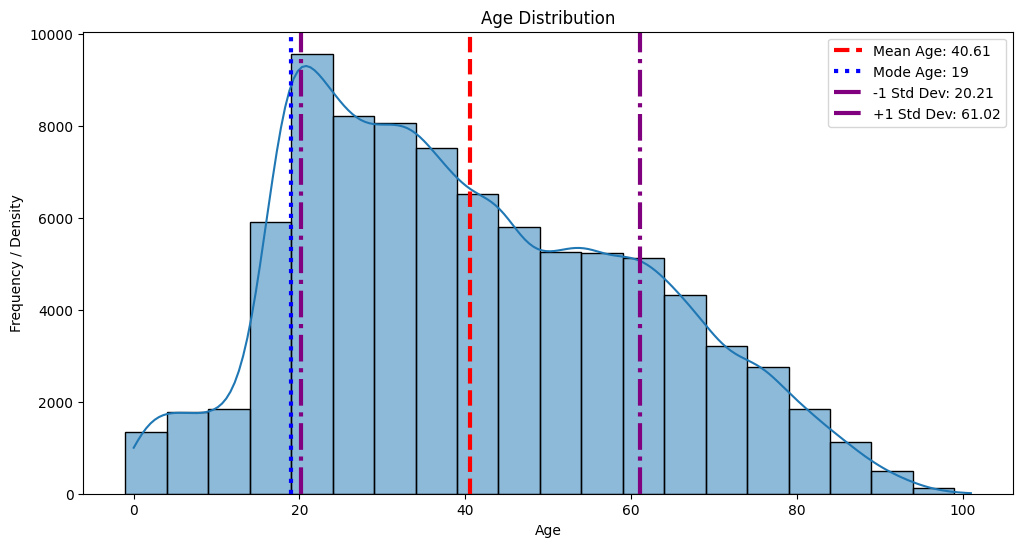

,AGE
count,86073.000000
mean,40.614397
std,20.408336
min,0.000000
25%,24.000000
50%,38.000000
75%,56.000000
max,101.000000


In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(age, bins=range(-1,101,5), kde=True)

mean_age = age.mean()
mode_age = age.mode()[0] # Get the first mode if there are multiple
std_age = age.std()

plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean Age: {mean_age:.2f}', linewidth=3)
plt.axvline(mode_age, color='blue', linestyle=':', label=f'Mode Age: {mode_age:.0f}', linewidth=3)
plt.axvline(mean_age - std_age, color='purple', linestyle='-.', label=f'-1 Std Dev: {(mean_age - std_age):.2f}', linewidth=3)
plt.axvline(mean_age + std_age, color='purple', linestyle='-.', label=f'+1 Std Dev: {(mean_age + std_age):.2f}', linewidth=3)
plt.legend()

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency / Density')

plt.show()
age.describe()